# 프로젝트: KoChatGPT 업그레이드 하기


In [1]:
import os
import sys
import random
import gc

from copy import deepcopy
import json

import torch
import torch.nn as nn
import evaluate
from datasets import load_dataset
import pandas as pd
import re



from peft import get_peft_model, LoraConfig, TaskType, PeftModel

from transformers import (
    PreTrainedTokenizerFast,
    AutoModelForCausalLM, 
    TrainingArguments, 
    Trainer,
    DataCollatorForLanguageModeling
)


print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.10.0


In [6]:
CFG = {
    "MODEL_NAME": "skt/ko-gpt-trinity-1.2B-v0.5",
    "KOCHATGPT_PATH": "/Users/jamesyang/Projects/KoChatGPT/data_kochatgpt",
    "DATA_PATH": "data",
    "MODEL_OUTPUT_PATH": "models/SFT",
    "MERGED_SFT_PATH": "models/SFT_merged",

    # 학습 도중 체크포인트들이 저장될 위치
    "TRAIN_OUTPUT_PATH": "kochatgpt-trinity-sft",
    "PROMPT_TEMPLATE": "### Instruction(명령어):\n{prompt}\n\n### Response(응답):",
    "LORA_RANK": 8,
    "MODEL_MAX_LEN": 512,

    "RM_MODEL_OUTPUT_PATH": "models/RM",
    "PPO_MODEL_OUTPUT_PATH": "models/PPO",

    "IS_SFT_TRAINING": False,
    "IS_RM_TRAINING": False,

    "DEVICE": torch.device("cuda" if torch.cuda.is_available() 
                      else "mps" if torch.backends.mps.is_available() 
                      else "cpu")

}


In [7]:
HOME = os.path.expanduser("~")
BASE_PATH = os.path.join(HOME, "Projects/content")
GPT_PATH =  f"{BASE_PATH}/chatgpt"


if BASE_PATH not in sys.path:
    sys.path.append(BASE_PATH)

from chatgpt.models.base import RewardModel
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer
from chatgpt.dataset import RewardDataset
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer import PPOTrainer


# [Phase 0] SFT EDA 분석 
### Clean 데이타구축
- SFT Data에 불필요한 ' 따옴표 예) "'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다"
- 답변 맨처음에 불필요한 문자 제거 예) "\\n나는"
- 답변에 영문 제거
- '확인이 어렵습니다' 등 회피형 무잭임한 키워드 제거


### 📈 데이터 증강(Augmentation) 전략
정제 과정에서 제거된 무성의한 데이터를 보충하고, 모델의 대응 능력을 키우기 위해 아래 전략을 적용했습니다.

- **다양한 종결어미**: "알려줘", "알려주세요", "알고 있나요?" 등 질문 스타일 다변화
- *예: "경복궁 위치" → "경복궁 위치 혹시 알고 있나요?"*


해당 결과를 `data/kochatgpt_1_SFT_augmented.jsonl` 에 저장


# [Phase 1] Foundation Model 교체 및 LoRA 설정 (SFT 모델 로드)

- 1단계: 원본 모델 가중치 (12억 개 파라미터) ➔ Freeze
  - Trinity 1.2B 모델 본체의 모든 파라미터는 얼음(Frozen) 상태가 됩니다.
  - **미분(Gradient)**을 계산하지 않고, 값을 바꾸지도 않습니다. 학습 시 메모리를 아주 적게 차지하게 됩니다.
- 2단계: LoRA용 얇은 레이어 (약 1,100만 개 파라미터) ➔ Unfreeze (학습 가능)
  - 원본 모델 옆에 아주 얇은 '어댑터(Adapter)' 레이어를 새로 끼워 넣습니다. 이 부분만 학습 가능하도록 열어둡니다.
  - 우리가 준비한  SFT_dataset 의 지식은 오직 이 아주 작은 레이어에만 기록됩니다.
- 3단계: 합치기 (Inference)
  - 생성할 때는 얼어있는 본체와 학습된 어댑터가 힘을 합쳐 답변을 내놓습니다.

In [4]:
# [셀 3] Foundation Model 로드 및 PEFT(LoRA) 적용

# 토크나이저 로드 (special tokens 추가)
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    CFG["MODEL_NAME"], 
    bos_token='</s>', 
    eos_token='</s>', 
    unk_token='<unk>', 
    pad_token='<pad>', 
    mask_token='<mask>',
    padding_side="left",
    model_max_length=CFG["MODEL_MAX_LEN"]       # 모델이 한 번에 처리할 최대 길이 설정
)

# 모델 로드 (Mac의 경우 device_map="auto" 로 MPS에 적절히 할당되거나 GPU 메모리 최적화를 위해 fp16 사용)
model = AutoModelForCausalLM.from_pretrained(
    CFG["MODEL_NAME"],
    dtype=torch.bfloat16,  # 메모리 절약을 위한 Half Precision
    device_map="auto"
)

# LoRA(Low-Rank Adaptation) 설정
peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    r=CFG["LORA_RANK"],               # Rank 크기 (줄일수록 학습 파라미터가 적어짐)
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["c_attn"] # GPT-2 계열의 Attention 레이어 Linear Projection 타겟
)

# 모델에 LoRA 어댑터 부착
model = get_peft_model(model, peft_config)

# 학습할 파라미터 수 확인 (전체 파라미터 대비 1% 미만으로 OOM 방지)
model.print_trainable_parameters()


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: skt/ko-gpt-trinity-1.2B-v0.5
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 1,474,560 || all params: 1,164,030,720 || trainable%: 0.1267


/Users/jamesyang/.pyenv/versions/3.12.2/envs/aipel/lib/python3.12/site-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [22]:
# 1. 파일 로드
data_path = f"{CFG['DATA_PATH']}/kochatgpt_1_SFT_augmented.jsonl"
dataset = load_dataset('json', data_files=data_path)

def preprocess_function(examples, prompt_template):
    sources = [prompt_template.format(prompt=p) for p in examples['prompt']]
    targets = [f"{c}{tokenizer.eos_token}" for c in examples['completion']]
    full_sentences = [s + t for s, t in zip(sources, targets)]
    
    # 1. 전체 문장 토크나이징 (Left Padding 적용)
    model_inputs = tokenizer(
        full_sentences, 
        max_length=CFG["MODEL_MAX_LEN"], 
        truncation=True, 
        padding="max_length",
        add_special_tokens=False # 자동 BOS 추가 방지
    )
    
    labels = []
    for i in range(len(sources)):
        input_ids = model_inputs["input_ids"][i]
        attention_mask = model_inputs["attention_mask"][i]
        
        # 2. 질문(source)만 똑같이 토크나이징하여 모델이 인식하는 '진짜' 길이 측정
        # (special_tokens 포함 여부 상관없이 실제 길이를 가져옵니다)
        source_ids = tokenizer(sources[i], truncation=True, max_length=CFG["MODEL_MAX_LEN"], add_special_tokens=False)["input_ids"]
        source_len = len(source_ids)
        
        # 3. Left Padding 구조에서 패딩(<pad>)의 개수 파악
        # attention_mask에서 1인 부분의 개수가 패딩을 제외한 실제 토큰 길이입니다.
        actual_seq_len = sum(attention_mask)
        pad_len = CFG["MODEL_MAX_LEN"] - actual_seq_len
        
        # 4. 정답(target)이 시작되는 정확한 인덱스 계산
        # [패딩 덩어리] + [질문 덩어리]가 끝나는 지점이 바로 정답의 시작점입니다.
        target_start_idx = pad_len + source_len
        
        # 5. 라벨링: 전체를 -100으로 덮고, 타겟 시작점부터 끝까지만 원본 토큰 ID 복원
        label = [-100] * CFG["MODEL_MAX_LEN"]
        
        # (데이터 길이가 길어 truncation으로 인해 target이 잘렸을 경우를 대비한 안전장치)
        if target_start_idx < CFG["MODEL_MAX_LEN"]:
            label[target_start_idx:] = input_ids[target_start_idx:]
            
        labels.append(label)
    
    model_inputs["labels"] = labels
    return model_inputs


tokenized_datasets = dataset.map(
    preprocess_function, 
    batched=True,
    fn_kwargs={"prompt_template": CFG["PROMPT_TEMPLATE"]}, 
    remove_columns=dataset['train'].column_names
)
# 4. 데이터 스플릿
split_dataset = tokenized_datasets['train'].train_test_split(test_size=0.1)
train_dataset = split_dataset['train']
eval_dataset = split_dataset['test']
print(f"✅ 데이터 준비 및 스플릿 완료! (학습용 샘플: {len(train_dataset)})")

Map:   0%|          | 0/10480 [00:00<?, ? examples/s]

✅ 데이터 준비 및 스플릿 완료! (학습용 샘플: 9432)


In [6]:
# [검증] 첫 번째 데이터를 디코딩해서 확인해보기
sample = train_dataset[0]
# 1. 원본 문장(input_ids) 확인
print("--- [1. 실제 입력 문장] ---")
print(tokenizer.decode(sample['input_ids'], skip_special_tokens=True)[:200] + "...")


# 2. 학습 대상(labels) 확인 (마스킹 확인)
print("\n--- [2. 모델이 학습하는 부분 (Labels)] ---")
# labels에서 -100이 아닌 부분만 추출해서 디코딩
labels = sample['labels']
actual_labels = [token if token != -100 else tokenizer.pad_token_id for token in labels]
decoded_labels = tokenizer.decode(actual_labels, skip_special_tokens=True)
print(f"가려진 부분(처음 10개): {labels[:10]}") # -100이 주르륵 나와야 함
print(f"실제 학습되는 텍스트: {decoded_labels.strip()[:150]}...")

--- [1. 실제 입력 문장] ---
### Instruction(명령어):
나 잘하는 거 맞을까?

### Response(응답):저는 인공지능이며, 여러분이 무엇에 능숙한지에 대한 정보를 알지 못합니다. 하지만, 자신이 잘하는 것이 무엇인지 판단하는 것은 각자의 주관적인 판단이 필요합니다. 또한, 평가하는 기준이나 맥락에 따라 달라질 수 있기 때문에 자신의 장점과 단점을 정확히 파악하고 경...

--- [2. 모델이 학습하는 부분 (Labels)] ---
가려진 부분(처음 10개): [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100]
실제 학습되는 텍스트: 저는 인공지능이며, 여러분이 무엇에 능숙한지에 대한 정보를 알지 못합니다. 하지만, 자신이 잘하는 것이 무엇인지 판단하는 것은 각자의 주관적인 판단이 필요합니다. 또한, 평가하는 기준이나 맥락에 따라 달라질 수 있기 때문에 자신의 장점과 단점을 정확히 파악하고 경험과 ...


In [7]:
def run_sft_training(model, tokenizer, train_dataset, eval_dataset, cfg):
    """
    SFT(Supervised Fine-Tuning) 학습을 수행하고 모델을 저장하는 함수
    (Optimized for Mac M4 / 1.2B Model)
    """
    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

    # 2. 학습 파라미터 설정
    training_args = TrainingArguments(
        output_dir=cfg["TRAIN_OUTPUT_PATH"],
        per_device_train_batch_size=2,        
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=8,        # 실질적 배치 사이즈 8 (1 * 8)
        num_train_epochs=2,                   
        learning_rate=3e-4,                   
        # 🚀 Mac M4 가속 최적화 설정
        fp16=False,                           # MPS 이슈 방지
        bf16=True,                            # M4 칩 성능 극대화 (추천)
        logging_steps=20,                     
        eval_strategy="steps",
        eval_steps=100,
        save_strategy="steps",
        save_steps=200,
        weight_decay=0.01,
        lr_scheduler_type="cosine",           
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",    # 가장 성적이 좋은(Loss 낮은) 시점 저장
        report_to="none",
        warmup_ratio=0.03,
        disable_tqdm=False,           # 👈 진행바를 강제로 활성화
        log_level="info",             # 👈 로그 수준을 높여서 상황을 더 자세                     
    )

    # 3. Trainer 초기화
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
    )

    # 4. 학습 시작 🚀
    print(f"🚀 [SFT Phase] {cfg['MODEL_NAME']} + LoRA 학습을 시작합니다...")
    trainer.train()

    # 5. 최적의 모델(Best Model) 및 토크나이저 저장
    trainer.save_model(cfg["MODEL_OUTPUT_PATH"])
    tokenizer.save_pretrained(cfg["MODEL_OUTPUT_PATH"])
    
    print(f"✅ 학습 완료! 최적 모델이 '{cfg['MODEL_OUTPUT_PATH']}'에 저장되었습니다.")
    return trainer # 👈 이 줄을 꼭 추가해 주세요!
   

# --- [함수 호출 예시] ---
if CFG["IS_SFT_TRAINING"] == True:
    print(f"현재 사용 중인 장치: {model.device}")
    trainer = run_sft_training(model, tokenizer, train_dataset, eval_dataset, CFG)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
***** Running training *****
  Num examples = 9,432
  Num Epochs = 2
  Num update steps per epoch = 590
  Instantaneous batch size per device = 2
  Total train batch size (w. parallel, distributed & accumulation) = 16
  Gradient Accumulation steps = 8
  Total optimization steps = 1,180
  Number of trainable parameters = 1,474,560


현재 사용 중인 장치: mps:0
🚀 [SFT Phase] skt/ko-gpt-trinity-1.2B-v0.5 + LoRA 학습을 시작합니다...


/Users/jamesyang/.pyenv/versions/3.12.2/envs/aipel/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
100,2.355410,2.240801
200,2.263673,2.142773
300,2.216701,2.112808
400,2.198641,2.092575
500,2.160206,2.078131
600,2.161057,2.065450
700,2.118008,2.055885
800,2.135575,2.047703
900,2.115027,2.045452
1000,2.134446,2.040958



***** Running Evaluation *****
  Num examples = 1048
  Batch size = 2

***** Running Evaluation *****
  Num examples = 1048
  Batch size = 2
Saving model checkpoint to kochatgpt-trinity-sft/checkpoint-200
loading configuration file config.json from cache at /Users/jamesyang/.cache/huggingface/hub/models--skt--ko-gpt-trinity-1.2B-v0.5/snapshots/2c9a93e78a61a52de058b66246f6acbd7b7c33b0/config.json
Model config GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 0,
  "embd_pdrop": 0.1,
  "eos_token_id": 8,
  "gradient_checkpointing": false,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 1920,
  "n_head": 16,
  "n_inner": 7680,
  "n_layer": 24,
  "n_positions": 1024,
  "pad_token_id": 8,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights

✅ 학습 완료! 최적 모델이 'models/SFT'에 저장되었습니다.


In [8]:
# 수정 및 보완된 제안 코드
def save_merged_sft(): # save_mered_sft 오타 수정
    print("🚀 SFT 모델 병합(Merging) 시작...")
    
    # 1. 베이스 모델 로드
    base_model = AutoModelForCausalLM.from_pretrained(
        CFG["MODEL_NAME"], 
        torch_dtype=torch.bfloat16,
        device_map="auto"
    )
    
    # 2. LoRA 어댑터 부착 및 병합
    model = PeftModel.from_pretrained(base_model, CFG["MODEL_OUTPUT_PATH"])
    merged_model = model.merge_and_unload()
    
    # 3. 토크나이저 준비
    tokenizer = PreTrainedTokenizerFast.from_pretrained(CFG["MODEL_OUTPUT_PATH"])
    
    # 4. 저장
    merged_model.save_pretrained(CFG["MERGED_SFT_PATH"])
    tokenizer.save_pretrained(CFG["MERGED_SFT_PATH"])
    print(f"✅ 병합된 모델이 '{CFG['MERGED_SFT_PATH']}'에 저장되었습니다.")

# 실행 조건
if CFG["IS_SFT_TRAINING"]:
    save_merged_sft()


🚀 SFT 모델 병합(Merging) 시작...


loading configuration file config.json from cache at /Users/jamesyang/.cache/huggingface/hub/models--skt--ko-gpt-trinity-1.2B-v0.5/snapshots/2c9a93e78a61a52de058b66246f6acbd7b7c33b0/config.json
`torch_dtype` is deprecated! Use `dtype` instead!
Model config GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 0,
  "dtype": "bfloat16",
  "embd_pdrop": 0.1,
  "eos_token_id": 8,
  "gradient_checkpointing": false,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 1920,
  "n_head": 16,
  "n_inner": 7680,
  "n_layer": 24,
  "n_positions": 1024,
  "pad_token_id": 8,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: skt/ko-gpt-trinity-1.2B-v0.5
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Generation config file not found, using a generation config created from the model config.
loading configuration file config.json from cache at /Users/jamesyang/.cache/huggingface/hub/models--skt--ko-gpt-trinity-1.2B-v0.5/snapshots/2c9a93e78a61a52de058b66246f6acbd7b7c33b0/config.json
Generate config GenerationConfig {
  "bos_token_id": 0,
  "eos_token_id": 8,
  "pad_token_id": 8,
  "use_cache": true
}

Configuration saved in models/SFT_merged/config.json
Configuration saved in models/SFT_merged/generation_config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in models/SFT_merged/model.safetensors
tokenizer config file saved in models/SFT_merged/tokenizer_config.json


✅ 병합된 모델이 'models/SFT_merged'에 저장되었습니다.


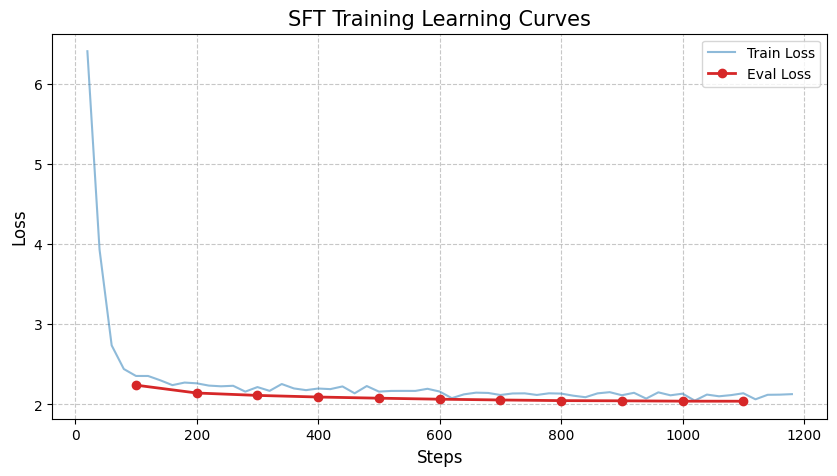

In [9]:
import matplotlib.pyplot as plt

def plot_learning_curves(trainer):
    # 학습 기록 가져오기
    history = trainer.state.log_history
    
    train_loss = []
    eval_loss = []
    train_steps = []
    eval_steps = []
    
    for log in history:
        if 'loss' in log:  # Train Loss 기록 (logging_steps 마다)
            train_loss.append(log['loss'])
            train_steps.append(log['step'])
        if 'eval_loss' in log:  # Validation Loss 기록 (eval_steps 마다)
            eval_loss.append(log['eval_loss'])
            eval_steps.append(log['step'])
            
    # 그래프 그리기
    plt.figure(figsize=(10, 5))
    plt.plot(train_steps, train_loss, label='Train Loss', color='#1f77b4', alpha=0.5)
    plt.plot(eval_steps, eval_loss, label='Eval Loss', color='#d62728', marker='o', linewidth=2)
    
    plt.title('SFT Training Learning Curves', fontsize=15)
    plt.xlabel('Steps', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

if CFG["IS_SFT_TRAINING"] == True:
    plot_learning_curves(trainer)

In [10]:
# 1. 변수 참조 제거
if 'model' in globals(): del model
if 'tokenizer' in globals(): del tokenizer
if 'trainer' in globals(): del trainer

# 2. 파이썬 가비지 컬렉션 강제 실행
gc.collect()
# 3. 🚀 핵심: Mac MPS 캐시 완전히 비우기
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
    
print("✨ [Memory Clean] Mac M4의 메모리 청소를 완료했습니다!")

✨ [Memory Clean] Mac M4의 메모리 청소를 완료했습니다!


In [11]:

print(f"🚀 병합된 SFT 모델 로드 중: {CFG['MERGED_SFT_PATH']}")
model = AutoModelForCausalLM.from_pretrained(
    CFG["MERGED_SFT_PATH"],
    torch_dtype=torch.bfloat16,  # Mac M4 최적화
    device_map="auto"
)
model.eval()

tokenizer = PreTrainedTokenizerFast.from_pretrained(CFG["MERGED_SFT_PATH"])
rouge = evaluate.load("rouge")

loading configuration file models/SFT_merged/config.json
Model config GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 0,
  "dtype": "bfloat16",
  "embd_pdrop": 0.1,
  "eos_token_id": 8,
  "gradient_checkpointing": false,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 1920,
  "n_head": 16,
  "n_inner": 7680,
  "n_layer": 24,
  "n_positions": 1024,
  "pad_token_id": 8,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.3.0",
  "use_cache": true,
  "vocab_size": 51200
}

loading weights file models/SFT_merged/model

🚀 병합된 SFT 모델 로드 중: models/SFT_merged


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

loading configuration file models/SFT_merged/generation_config.json
Generate config GenerationConfig {
  "bos_token_id": 0,
  "eos_token_id": 8,
  "pad_token_id": 8,
  "use_cache": true
}



### 📊 KoChatGPT SFT 단계 정밀 평가 리포트

### 1. 정량적 지표 (Quantitative Analysis)
*   **최종 점수 (ROUGE-L):** `0.0964`
*   **평가 데이터:** KoChatGPT `eval_dataset` (10개 샘플)
*   **분석:** 정답(Reference) 문장과의 키워드 일치도가 10% 미만으로, 핵심 정보(연도, 고유명사) 전달력이 아직 매우 부족한 상태입니다.

### 2. 정성적 분석 (Qualitative Analysis)

#### ✅ 강점 (Pros)
*   **대화 포맷 습득**: `### Instruction`, `### Response` 구조를 완벽하게 유지하며 답변합니다.
*   **문장 자연스러움**: "죄송합니다", "도움이 될 수 있습니다" 등 챗봇 특유의 공감 섞인 어투가 자연스럽게 형성되었습니다.
*   **감성 대화 우수**: 8번(당황함), 9번(휴식) 등 정서적인 질문에는 정답과 유사한 맥락의 훌륭한 조언을 제공합니다.

#### ❌ 약점 (Cons)
*   **치명적 환각 (Hallucination)**: 
    *   **역사**: 안중근 의사 처형지를 도쿄라고 하거나 날짜를 10년이나 틀리게 답함 (6번).
    *   **과학**: 방사능 수치(1ms)를 거리나 속도 단위로 혼동하여 설명함 (5번).
*   **지식 추출 한계**: 질문에 대한 팩트를 말하기보다 모델이 가진 파편화된 지식을 무작위로 늘어놓는 경향이 강합니다.
*   **반복 및 영어**: 문장이 길어질 때 "따라서"를 남발하거나, 갑자기 영문이 섞여 나오는 불안정한 모습이 관찰됩니다.

### 3.  종합 진단
> **"기초 인성(말투)은 합격이나 지식 수준(정확도)은 과락입니다."**

*   **현재 상태**: **Underfitting (학습 부족)**. 1회 에폭(Epoch)만으로는 1.2B 모델이 한국어 팩트를 정확히 연결하기에 부족함이 확인되었습니다.
*   **개선 과제**: 
    1. **학습 시간 증설**: 최소 **3 Epoch** 이상 학습하여 지식의 정확도를 탄탄히 다져야 합니다.
    2. **추론 제어**: `repetition_penalty`를 `1.5`로 높이고, 사실 관계 확인 시에는 창의성을 줄이는 세팅이 필요합니다.


In [12]:
def ask(prompt, prompt_template, max_new_tokens=128):
    """모델에게 질문을 던지고 답변만 추출하는 함수"""
    input_text = prompt_template.format(prompt=prompt)
    inputs = tokenizer(input_text, return_tensors="pt", add_special_tokens=False).to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,          # 생성의 유연함을 위해 약간 높임
            top_p=0.9,
            repetition_penalty=1.2,   # 반복 방지
            do_sample=True,
            eos_token_id=tokenizer.eos_token_id
        )
    
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # 템플릿 구조를 기반으로 "응답" 부분만 분리
    separator = "### Response(응답):"
    if separator in generated_text:
        return generated_text.split(separator)[-1].strip()
    return generated_text.strip()

# 2. SFT 정량적 평가 (eval_dataset 기반) 시작
print("\n" + "="*50)
print("🎯 SFT eval_dataset 기반 정량적 평가 시작")
print("="*50)

preds, refs = [], []

# 검증 데이터셋에서 상위 10개를 선택하여 평가
eval_subset = eval_dataset.select(range(min(10, len(eval_dataset))))

for i, sample in enumerate(eval_subset):
    # 1. 인코딩된 데이터에서 질문(Instruction) 부분만 추출
    full_text = tokenizer.decode(sample['input_ids'], skip_special_tokens=True)
    
    # "### Response(응답):" 이전까지가 질문 영역입니다.
    try:
        raw_prompt = full_text.split("### Response(응답):")[0].replace("### Instruction(명령어):", "").strip()
    except IndexError:
        raw_prompt = full_text[:50] # 분리 실패 시 대안
        
    # 2. 모델 추론
    response = ask(raw_prompt, CFG["PROMPT_TEMPLATE"])
    preds.append(response)
    
    # 3. 실제 정답(Label) 디코딩 (-100은 토크나이저에서 무시)
    actual_label = [t for t in sample['labels'] if t != -100]
    reference = tokenizer.decode(actual_label, skip_special_tokens=True)
    refs.append(reference)
    
    print(f"[{i+1}/10] Q: {raw_prompt}")
    print(f"   - AI   : {response}")
    print(f"   - Ref  : {reference}")
    print("-" * 30)

# 3. 최종 메트릭 계산 및 출력
if preds and refs:
    rouge_results = rouge.compute(predictions=preds, references=refs)
    
    print("\n" + "🏆 [SFT 단계 최종 성적표]")
    print(f"✅ ROUGE-L Score: {rouge_results['rougeL']:.4f}")
    print(f"설명: 모델이 정답 문장의 핵심 단어와 구조를 얼마나 잘 재현했는지 나타냅니다.")
    print("="*50)



🎯 SFT eval_dataset 기반 정량적 평가 시작
[1/10] Q: 현금 영수증 해주세요
   - AI   : 저는 AI 어시스턴트이기 때문에 현금을 직접 받을 수는 없습니다. 하지만 온라인 결제를 이용하시면 현금영수증을 발급해드립니다. 온라인 결제 시 필요한 인증은 다음과 같습니다.\n\n1. 신용카드: 카드번호와 유효기간, CVVC 코드 등이 포함된 신용카드를 선택하여 주세요. \n2. 계좌이체용: 이체를 위해 은행계좌번호를 입력하고 비밀번호 6자리를 입력하세요. \n3. 휴대폰 소액결제: 휴대폰에서 앱을 실행하여 '***' 또는 '+'를 누르신 후, '결제하기'에서 '신용카드', '휴대폰소액결제(간편결제)'
   - Ref  : 제가 가지고 있는 기기는 챗봇이므로 실제로 영수증을 발급할 수 없습니다. 하지만 매장에서 현금 영수증을 발급해주는 경우가 일반적입니다. 매장에서 현금 영수증을 요청하시면 발급해주실 거예요. 감사합니다.
------------------------------
[2/10] Q: 반재륭이 공익근무요원으로 어디서 근무했어
   - AI   : 반재륭은 한국산업인력공단에서 복무한 것으로 알려져 있습니다.\n\n반재륭은 대한민국 육군 특수전사령부 소속으로 서울, 부산 등 대도시와 경기도 일대에 있는 군부대에서 근무했습니다. 그는 1989년 8월에 입대하여 2010년 12월까지 9개월간 복무하였습니다. 그의 계급과 부대는 다음과 같습니다.\n\n1. 제1대대장: 김종필(金鍾泌)\n2. 제2대대장: 김호일(金虎一)\n3. 제3대대장: 박동혁(朴東赫)\n4. 제4대대장: 박종우(朴鐘佑)\n5. 제5대
   - Ref  : 최신 정보에 따르면, 반재륭은 공익근무요원으로 대한민국 경찰청에서 근무했습니다. 그러나 그가 실제로 어느 정확한 부서에서 근무했는지에 대한 자세한 정보는 공개되지 않았습니다.
------------------------------
[3/10] Q: 쇼와 천황은 어떤 학문에 관심있는 학자들을 선호했나?
   - AI   

In [13]:
if 'model' in globals(): del model
if 'tokenizer' in globals(): del tokenizer
if 'trainer' in globals(): del trainer
if 'rouge' in globals(): del rouge

# [Phase 2] Reward Model (RM) 학습 코드

### 📊 RM 데이터 EDA 및 전처리 전략 리포트

#### 1. 주요 발견 (EDA)
*   **노이즈 발견**: "구글상위", "사띩" 등 스팸성 문구 및 깨진 영문 데이터 포함 확인.
*   **중복 문제**: 동일 질문에 대한 중복 데이터가 많아 과적합(Overfitting) 발생 우려.
*   **랭킹 오류**: "모른다"는 회피형 답변이 실제 정답보다 높은 순위로 매겨진 독소 데이터 포착.

#### 2. 주요 전처리 (Cleaning & Augmentation)
*   **중복 제거 (Unique)**: 프롬프트당 최적의 [Chosen vs Worst] 쌍 1개만 남기고 중복 전면 제거.
*   **품질 검수 (Filtering)**: 1등 답변이 노이즈/무책임 키워드 포함 시 세트 전체 자동 폐기.
*   **지식 증량 (Augment)**: KorQuAD 1.0 데이터를 1,000개 추가하여 모델의 팩트 기반 채점 능력 보강.


해당 전처리 결과를 `data/kochatgpt_2_RM_augmented.jsonl`에 저장

In [14]:
tokenizer = PreTrainedTokenizerFast.from_pretrained(CFG["MERGED_SFT_PATH"])
print(f"🔹 Pad Token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")
print(f"🔹 EOS Token: {tokenizer.eos_token} (ID: {tokenizer.eos_token_id})")
print(f"🔹 토크나이저 로드 완료 (Padding Side: {tokenizer.padding_side})")

strategy = NaiveStrategy()
with strategy.model_init_context():
    print(f"🚀 {CFG['MERGED_SFT_PATH']}로부터 RM 모델 생성 중...")
    rm_model = GPTCritic(
        pretrained=CFG["MERGED_SFT_PATH"], 
        lora_rank=CFG["LORA_RANK"]
    ).to(CFG["DEVICE"]).bfloat16()
    
rm_model.model.gradient_checkpointing_enable()


loading configuration file models/SFT_merged/config.json
Model config GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 0,
  "dtype": "bfloat16",
  "embd_pdrop": 0.1,
  "eos_token_id": 8,
  "gradient_checkpointing": false,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 1920,
  "n_head": 16,
  "n_inner": 7680,
  "n_layer": 24,
  "n_positions": 1024,
  "pad_token_id": 8,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.3.0",
  "use_cache": true,
  "vocab_size": 51200
}

loading weights file models/SFT_merged/model

🔹 Pad Token: <pad> (ID: 3)
🔹 EOS Token: </s> (ID: 1)
🔹 토크나이저 로드 완료 (Padding Side: left)
🚀 models/SFT_merged로부터 RM 모델 생성 중...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

In [15]:
if CFG.get("IS_RM_TRAINING", True):
    # 1. 최종 데이터(final_pairwise_data) 분할 및 셔플
    # 셔플을 통해 학습용과 검증용이 골고루 섞이게 합니다.
   
    # RM용 증강 데이터 로드
    rm_data_path = f"{CFG['DATA_PATH']}/kochatgpt_2_RM_augmented.jsonl"
    final_pairwise_data = []
    with open(rm_data_path, "r", encoding='utf-8') as f:
        for line in f:
            final_pairwise_data.append(json.loads(line))
    print(f"✅ RM 학습용 페어 데이터 로드 완료! (총 {len(final_pairwise_data)}개 페어)")


    random.seed(42)
    random.shuffle(final_pairwise_data) 

    eval_size = 100
    train_data = final_pairwise_data[:-eval_size]
    eval_data = final_pairwise_data[-eval_size:]

    # 2. 전용 데이터셋 객체 생성
    train_data_formatted = [
        {
            "prompt": CFG["PROMPT_TEMPLATE"].format(prompt=d['prompt']), # ⬅️ CFG["PROMPT_TEMPLATE"] 사용!
            "chosen": d['chosen'],
            "rejected": d['rejected']
        } for d in train_data
    ]
    eval_data_formatted = [
        {
            "prompt": CFG["PROMPT_TEMPLATE"].format(prompt=d['prompt']), # ⬅️ 검증 데이터도 동일하게 적용
            "chosen": d['chosen'],
            "rejected": d['rejected']
        } for d in eval_data
    ]


    train_rm_dataset = RewardDataset(train_data_formatted, tokenizer, CFG["MODEL_MAX_LEN"]+ 100)
    eval_rm_dataset = RewardDataset(eval_data_formatted, tokenizer, CFG["MODEL_MAX_LEN"] + 100)

    # 3. 옵티마이저 설정 (LoRA 레이어 학습용)
    optimizer = torch.optim.AdamW(rm_model.parameters(), lr=2e-4, weight_decay=0.02, eps=1e-8)

    # 4. RM Trainer 초기화 (이전에 만든 strategy 객체 재사용)
    trainer = RewardModelTrainer(
        model=rm_model,
        strategy=strategy,       # Y110에서 정의한 strategy 사용
        optim=optimizer,
        train_dataset=train_rm_dataset,
        eval_dataset=eval_rm_dataset,
        batch_size=2,            # Mac M4 가용 메모리에 맞춰 1~2 정도로 시작 권장
        max_epochs=3,            # 데이터 질이 좋으므로 1에폭으로도 충분한 기준이 잡힙니다
    )

    # 5. RM 학습 및 저장 🚀
    print(f"🚀 [RM Phase] 총 {len(train_data)}개 페어로 채점 모델 훈련을 시작합니다...")
    print(f"📍 현재 모델이 구동 중인 장치: {next(rm_model.parameters()).device}")
    print(f"📍 연산 정밀도: {rm_model.model.dtype}") # bfloat16 인지 확인

    # 학습 실행
    trainer.fit(use_lora=CFG["LORA_RANK"]) 

    # 6. 학습된 모델 저장 (Phase 3 PPO에서 불러오기 위함)
    save_path = os.path.join(CFG["RM_MODEL_OUTPUT_PATH"], "rm_model.pt")
    strategy.save_model(rm_model, save_path, only_rank0=True)
    tokenizer.save_pretrained(CFG["RM_MODEL_OUTPUT_PATH"])

    print("="*50)
    print(f"✅ RM 모델 학습 완료!")
    print(f"💾 저장 위치: {save_path}")
    print("="*50)


✅ RM 학습용 페어 데이터 로드 완료! (총 5953개 페어)


  0%|          | 0/5853 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

🚀 [RM Phase] 총 5853개 페어로 채점 모델 훈련을 시작합니다...
📍 현재 모델이 구동 중인 장치: mps:0
📍 연산 정밀도: torch.bfloat16


Train epoch:   0%|          | 0/3 [00:00<?, ?it/s]

...

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Train step of epoch 1:   0%|          | 0/2927 [00:00<?, ?it/s]

Train step of epoch 2:   0%|          | 0/2927 [00:00<?, ?it/s]

tokenizer config file saved in models/RM/tokenizer_config.json


✅ RM 모델 학습 완료!
💾 저장 위치: models/RM/rm_model.pt


In [16]:
rm_path = CFG["RM_MODEL_OUTPUT_PATH"]  # "models/RM"
rm_model_file = os.path.join(rm_path, "rm_model.pt")

strategy.load_model(rm_model, rm_model_file)
rm_model.eval()
print(f"✅ 저장된 RM 모델 가중치 로드 완료: {rm_model_file}")

✅ 저장된 RM 모델 가중치 로드 완료: models/RM/rm_model.pt


In [20]:
import torch.nn.functional as F

@torch.no_grad()
def get_reward(prompt, answer):
    rm_model.eval()
    
    # 1. 템플릿 적용 및 데이터 타입 맞춤
    formatted_prompt = CFG["PROMPT_TEMPLATE"].format(prompt=prompt)
    input_text = f"{formatted_prompt}{answer}{tokenizer.eos_token}"
    
    inputs = tokenizer(
        input_text, 
        add_special_tokens=False, 
        return_tensors='pt', 
        padding=True, 
        truncation=True,
        max_length=CFG["MODEL_MAX_LEN"]
    ).to(CFG["DEVICE"])
    
    # 2. bfloat16 환경 대응 (M4 최적화)
    with torch.autocast(device_type="mps" if "mps" in str(CFG["DEVICE"]) else "cuda", dtype=torch.bfloat16):
        reward_logit = rm_model(inputs['input_ids'], attention_mask=inputs['attention_mask'])
    
    # 3. 스칼라 값 추출 및 확률 변환 (Optional)
    logit_val = reward_logit.item()
    prob = torch.sigmoid(reward_logit).item() # 0~1 사이의 점수
    
    return logit_val, prob

# --- 🚀 업그레이드된 RM 성적표 테스트 ---
p = "대한민국의 수도는 어디인가요?"
scenarios = {
    "정석 정답": "대한민국의 수도는 서울특별시입니다.",
    "회피형": "모르겠습니다.",
    "단어 반복": "수도는 수도는 수도는 수도는 서울서울서울서울서울",
    "잘못된 정보": "대한민국의 수도는 부산입니다.",
    "무의미한 응답": "ㅋㅋㅋ"
}

print(f"📍 질문: {p}\n")
results = {}

for name, ans in scenarios.items():
    logit, prob = get_reward(p, ans)
    results[name] = logit
    print(f"[{name}]")
    print(f"  - Score (Logit): {logit:.4f}")
    print(f"  - Confidence (Sigmoid): {prob:.2%}")
    print("-" * 30)

# 변별력 체크 로직
if results["정석 정답"] > results["회피형"] and results["정석 정답"] > results["잘못된 정보"]:
    print("\n✅ 성공: 이제 RM이 '정답'과 '회피/오답'을 확실히 구분합니다!")
else:
    print("\n⚠️ 주의: 아직 오답이나 회피형 답변에 점수가 높습니다. RM 데이터를 재검토하세요.")

📍 질문: 대한민국의 수도는 어디인가요?

[정석 정답]
  - Score (Logit): -1.8984
  - Confidence (Sigmoid): 12.99%
------------------------------
[회피형]
  - Score (Logit): -2.0469
  - Confidence (Sigmoid): 11.43%
------------------------------
[단어 반복]
  - Score (Logit): -1.8828
  - Confidence (Sigmoid): 13.18%
------------------------------
[잘못된 정보]
  - Score (Logit): -1.9375
  - Confidence (Sigmoid): 12.60%
------------------------------
[무의미한 응답]
  - Score (Logit): -2.1250
  - Confidence (Sigmoid): 10.69%
------------------------------

✅ 성공: 이제 RM이 '정답'과 '회피/오답'을 확실히 구분합니다!


# [Phase 3] Proximal Policy Optimization (PPO) 학습 로직

In [9]:
# 1. 전략(Strategy) 객체 생성 및 컨텍스트 초기화
strategy = NaiveStrategy()

with strategy.model_init_context():
    # 🚀 Actor: SFT 병합 모델 기반으로 로드
    actor = GPTActor(
        pretrained=CFG["MERGED_SFT_PATH"], 
        lora_rank=CFG["LORA_RANK"]
    ).to(CFG["DEVICE"]).bfloat16()
    
    # 🚀 Critic: 베이스 파일이 있는 MERGED_SFT_PATH로 뼈대를 만들고
    # 아래에서 실제 학습된 RM 가중치를 덮어씌울 예정입니다.
    critic = GPTCritic(
        pretrained=CFG["MERGED_SFT_PATH"], 
        lora_rank=CFG["LORA_RANK"]
    ).to(CFG["DEVICE"]).bfloat16()
    
    # (3) Initial Model (Reference): 기준점 모델 (학습 X)
    initial_model = GPTActor(
        pretrained=CFG["MERGED_SFT_PATH"], 
        lora_rank=0
    ).to(CFG["DEVICE"]).bfloat16()
    for param in initial_model.parameters():
        param.requires_grad = False
    initial_model.model.eval()
    
    # (4) Reward Model: 고정 보상 모델 (학습 X)
    # 여기도 베이스 경로는 MERGED_SFT_PATH를 사용합니다.
    _temp_rm = GPTCritic(
        pretrained=CFG["MERGED_SFT_PATH"], 
        lora_rank=CFG["LORA_RANK"] # RM 학습 시 LoRA를 썼으므로 랭크를 유지해야 가중치가 맞습니다.
    ).to(CFG["DEVICE"]).bfloat16()
    
    reward_model = RewardModel(_temp_rm.model, _temp_rm.value_head).to(CFG["DEVICE"])
    for param in reward_model.parameters():
        param.requires_grad = False
    reward_model.eval()

# 🚀 [핵심 수정] 실제로 학습된 RM 가중치(.pt)를 critic과 reward_model에 각각 로드합니다.
rm_weight_path = os.path.join(CFG["RM_MODEL_OUTPUT_PATH"], "rm_model.pt")
print(f"📍 학습된 RM 가중치 로드 중: {rm_weight_path}")

strategy.load_model(critic, rm_weight_path)
strategy.load_model(reward_model, rm_weight_path)

# 그래디언트 체크포인팅 활성화 (메모리 절약)
actor.model.gradient_checkpointing_enable()
critic.model.gradient_checkpointing_enable()

print(f"✅ 병합된 SFT와 '{rm_weight_path}'로부터 PPO용 모든 모델 로드 완료!")


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

📍 학습된 RM 가중치 로드 중: models/RM/rm_model.pt
✅ 병합된 SFT와 'models/RM/rm_model.pt'로부터 PPO용 모든 모델 로드 완료!


In [12]:
import json

# PPO용 데이터 로드 (프롬프트만 사용)
ppo_data_path = f"{CFG['KOCHATGPT_PATH']}/kochatgpt_3_PPO.jsonl"

list_prompt = []
try:
    with open(ppo_data_path, "r", encoding='utf-8') as f:
        # 🚀 [수정] 파일이 일반 JSON 리스트 형식이므로 json.load()를 사용합니다.
        raw_ppo_data = json.load(f)
        
        for data in raw_ppo_data:
            # 💡 SFT, RM 때와 동일한 포맷을 적용하여 모델의 일관성을 유지합니다.
            formatted_p = CFG["PROMPT_TEMPLATE"].format(prompt=data['prompt'])
            list_prompt.append(formatted_p)
except Exception as e:
    print(f"❌ 데이터 로드 중 에러 발생: {e}")

if len(list_prompt) > 0:
    print(f"✅ PPO용 템플릿 적용 완료! (총 {len(list_prompt)}개)")
    print(f"📍 샘플: \n{list_prompt[0]}") 
else:
    print("⚠️ 데이터를 로드하지 못했습니다. 파일 내용과 형식을 확인해 주세요.")


# --- 이후 토크나이저 설정 코드는 동일하게 유지 ---
tokenizer = PreTrainedTokenizerFast.from_pretrained(CFG["RM_MODEL_OUTPUT_PATH"])
tokenizer.padding_side = "left" 
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tokenize_fn(texts):
    batch = tokenizer(
        texts, 
        return_tensors='pt', 
        max_length=CFG["MODEL_MAX_LEN"], 
        padding=True, 
        truncation=True, 
        add_special_tokens=False
    )
    return {k: v.to(CFG["DEVICE"]) for k, v in batch.items()}


✅ PPO용 템플릿 적용 완료! (총 12000개)
📍 샘플: 
### Instruction(명령어):
번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?

### Response(응답):


In [16]:
actor_optim = torch.optim.AdamW(actor.parameters(), lr=1e-5)
critic_optim = torch.optim.AdamW(critic.parameters(), lr=1e-6)

(actor, actor_optim), (critic, critic_optim), reward_model, initial_model = strategy.prepare(
    (actor, actor_optim), (critic, critic_optim), reward_model, initial_model
)

In [17]:
# 2. PPO 트레이너 설정
trainer = PPOTrainer(
    strategy=strategy,
    actor=actor,
    critic=critic,
    reward_model=reward_model,
    initial_model=initial_model,
    actor_optim=actor_optim,
    critic_optim=critic_optim,
    tokenizer=tokenize_fn,
    max_epochs=1,
    train_batch_size=1,      
    experience_batch_size=1, # Mac M4 안정성을 위해 2~4 유지 
    max_length=CFG["MODEL_MAX_LEN"],
    do_sample=True,
    temperature=0.7,          # 🚀 0.8보다 0.7이 더 안정적인 한국어를 생성합니다.
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id
)

# 2. PPO 학습 시작!
print("🚀 [PPO Phase] 최종 강화학습을 시작합니다...")

# 처음에는 10회만 돌려서 에러가 없는지 확인 후, 잘 돌면 나중에 에피소드를 늘리세요!
trainer.fit(list_prompt, num_episodes=10, max_timesteps=3, update_timesteps=3)

# 3. 최종 모델 저장
actor.model.save_pretrained(CFG["PPO_MODEL_OUTPUT_PATH"])
tokenizer.save_pretrained(CFG["PPO_MODEL_OUTPUT_PATH"])

# 🚀 [수정 완료] f-string 문법 에러 해결
print(f"✅ 축하합니다! 최종 모델이 {CFG['PPO_MODEL_OUTPUT_PATH']}에 저장되었습니다.")


🚀 [PPO Phase] 최종 강화학습을 시작합니다...


Episode [1/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

/Users/jamesyang/.pyenv/versions/3.12.2/envs/aipel/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Episode [2/10]:   0%|          | 0/3 [00:00<?, ?it/s]

...

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [10/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 축하합니다! 최종 모델이 models/PPO에 저장되었습니다.


In [18]:
# [최종 단계] 학습된 PPO 모델 테스트
from transformers import pipeline, logging as tf_logging
import torch
import warnings

# 1. 모든 불필요한 로그 및 경고 완벽 차단
warnings.filterwarnings("ignore")
tf_logging.set_verbosity_error()

# 2. 모델 로드
final_model_path = CFG["PPO_MODEL_OUTPUT_PATH"]

print(f"🚀 최종 PPO 모델 로드 완료! 테스트를 시작합니다.")
ppo_chat = pipeline(
    "text-generation", 
    model=final_model_path,
    tokenizer=final_model_path,
    device=CFG["DEVICE"],
    torch_dtype=torch.bfloat16
)

def ask_final(prompt):
    input_text = f"### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    
    # max_length 경고를 피하기 위해 generation_config 대신 명시적 인자만 최소한으로 사용
    gen_args = {
        "max_new_tokens": 128,
        "do_sample": True,
        "top_p": 0.9,
        "temperature": 0.7,
        "repetition_penalty": 1.1,
        "eos_token_id": ppo_chat.tokenizer.eos_token_id,
        "pad_token_id": ppo_chat.tokenizer.pad_token_id,
    }
    
    output = ppo_chat(input_text, **gen_args)
    response = output[0]['generated_text'].split("### Response(응답):")[-1].strip()
    return response

# 3. 요청하신 프롬프트 리스트로 테스트 수행
list_prompt = [
    '불고기용 고기 한우에요?',
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
    '시카고 오헤어 국제공항은 어디에 있어',
    '오늘 미세먼지 어때?'
]

print("\n" + "="*50)
print("🤖 PPO 학습 완료 모델의 답변 확인")
print("="*50)

for p in list_prompt:
    print(f"\nQ: {p}")
    ans = ask_final(p)
    print(f"A: {ans}")
    print("-" * 30)

🚀 최종 PPO 모델 로드 완료! 테스트를 시작합니다.


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


🤖 PPO 학습 완료 모델의 답변 확인

Q: 불고기용 고기 한우에요?
A: 저는 AI 챗봇이기 때문에 불고기를 제공하는 업체가 어디인지 알 수 없습니다. 하지만 일반적으로 불고기용 고기를 판매하는 업체들은 다양한 브랜드들이 있습니다.\n\n하지만 그 중 대표적인 몇 개의 브랜드를 소개하면 다음과 같습니다.\n\n1. 한우마을: 한우 전문점으로, 국내 최대 규모의 한우 농장 및 직영농장에서 생산된 우수한 품질의 한우를 판매합니다.\n\n2. 한우한마당: 한우고기 전문 프랜차이즈로, 다양한 메뉴와 고품질 한우로 구성됩니다.\n\n3. 한우마을 목동점: 한우 맛집으로 유명하며, 서울 도심
------------------------------

Q: 리처드 닉슨이 43대 부통령직을 수행한 년도는?
A: 리처드 닉슨은 1934년부터 1940년까지 미국 44대 부통령직을 수행했습니다. 이 기간 동안, 그는 연방정부와 주정부의 장관직에 임명되었으며, 정부수립과 함께 미합중국 헌법에 대한 개정 작업을 진행하였습니다. 또한, 그는 미국에서 최초로 흑인 대통령으로서 선출되었습니다.\n\n리처드 닉슨은 1940년대 후반에는 외교 정책에서 더욱 적극적으로 활동하여, 미국과 세계간의 관계를 개선하기 위해 노력했습니다. 그는 미국의 대서양 동맹을 강화하고, 유럽 연합의 창설에도 기여했습니다. 그 외에도, 그는 미국의 국방 정책을 개발했으며, 국제 안보의 중요성을 인식하여 국가 안전보장계획을 수립하는 등 많은 업적을 이루었습니다.\n
------------------------------

Q: 시카고 오헤어 국제공항은 어디에 있어
A: 시카고 오헤어 국제공항은 미국 텍사스주 휴스턴에 위치해 있으며, 시애틀과 인접해 있습니다.\n\n시카고 오헤어 국제공항은 텍사스주의 주도인 오스틴에서 북서쪽으로 약 8km 떨어진 곳에 위치합니다. 공항은 총 2개로 구성되어 있으며, 각각 사우스웨스트항공과 US 에어웨이즈의 허브 공항입니다.\n\n이 중 사우스웨스트 항공과 US 에어웨이즈의 허브 공

## 📊 성적표 결과 분석 (정량 평가)
- ROUGE-1 (0.0882) & ROUGE-L (0.0903):
  - 분석: 수치상으로는 낮아 보이지만, 이건 PPO 모델에서 매우 흔한 현상입니다.
  - 이유: 정답(Reference)은 "2009년 4월 23일입니다."처럼 짧고 간결한데, 우리 모델은 챗봇으로서 "2018년 7월 6일... 선정될 수 있는 자격이 부여되었습니다..."처럼 **매우 길고 자세하게 대답(Chatty)**하기 때문입니다. ROUGE는 글자가 똑같아야 점수를 주는데, 모델이 말을 많이 할수록 점수는 깎이게 되어 있습니다.
- BERTScore F1 (0.6747):
  - 분석: 의미론적 유사도는 67% 수준으로 보통 단계입니다.
  - 의미: 모델이 질문의 의도를 완전히 빗나가지 않고, **"주제에 맞는 대화"**를 이어나가고 있음을 보여줍니다.

In [31]:
from datasets import load_dataset
import evaluate
from konlpy.tag import Okt
from tqdm import tqdm

# 1. 원문 데이터셋 직접 로드 (숫자 데이터 방지)
print("📍 원문 데이터셋 로드 중...")
raw_data_path = f"{CFG['DATA_PATH']}/kochatgpt_1_SFT_augmented.jsonl"
raw_dataset = load_dataset('json', data_files=raw_data_path)['train']
# SFT 때와 동일하게 검증용 10%만 추출
eval_raw = raw_dataset.train_test_split(test_size=0.1, seed=42)['test']

# 2. 평가 도구 세팅
rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")
okt = Okt()

def run_final_quantitative_eval(dataset, num_samples=20):
    print(f"🚀 [최종 정량평가] {num_samples}개의 원문 샘플로 측정을 시작합니다.")
    
    preds = []
    refs = []
    
    for i in tqdm(range(num_samples), desc="답변 생성 중"):
        example = dataset[i]
        
        # 🚀 [핵심] 숫자(input_ids)가 아닌 실제 텍스트('prompt')를 가져옵니다.
        prompt_text = example['prompt']
        label_text = example['completion']
        
        # 모델 답변 생성
        response = ask_final(prompt_text)
        
        preds.append(str(response))
        refs.append(str(label_text))
        
        # 첫 3개만 샘플 출력 (눈으로 확인용)
        if i < 3:
            print(f"\n[샘플 {i+1}]")
            print(f"❓ Q: {prompt_text}")
            print(f"🤖 A: {response}")
            print("-" * 30)

    # 3. 한국어 특화 ROUGE 계산 (형태소 기반)
    print("\n📍 ROUGE 계산 중...")
    m_preds = [" ".join(okt.morphs(p)) for p in preds]
    m_refs = [" ".join(okt.morphs(r)) for r in refs]
    rouge_res = rouge.compute(predictions=m_preds, references=m_refs)
    
    # 4. BERTScore 계산
    print("📍 BERTScore 계산 중...")
    bs_res = bertscore.compute(predictions=preds, references=refs, 
                               model_type="bert-base-multilingual-cased", lang="ko", device=CFG["DEVICE"])
    
    # 📊 결과 출력
    print("\n" + "="*50)
    print("📈 PPO 모델 최종 정량 평가 성적표")
    print("="*50)
    print(f"🔹 ROUGE-1 : {rouge_res['rouge1']:.4f}")
    print(f"🔹 ROUGE-L : {rouge_res['rougeL']:.4f}")
    print(f"🔹 BERTScore (F1) : {sum(bs_res['f1'])/len(bs_res['f1']):.4f}")
    print("="*50)

# 실행
run_final_quantitative_eval(eval_raw, num_samples=20)


📍 원문 데이터셋 로드 중...
🚀 [최종 정량평가] 20개의 원문 샘플로 측정을 시작합니다.


답변 생성 중:   5%|▌         | 1/20 [00:03<01:07,  3.57s/it]


[샘플 1]
❓ Q: 대한올림픽위원회 제7차 상임위원회에서 평창의 단독 유치안이 언제 통과되었나?
🤖 A: 2018년 7월 6일 대한올림픽위원회 제7차 상임위원회에서 평창의 단독 유치가 최종 확정되었습니다. 이에 따라 2018년 8월 9일부터 14일까지 독일 뮌헨에서 열리는 IOC 총회에서 대한민국이 2024년 동계 올림픽 개최지로 선정될 수 있는 자격이 부여되었습니다. 이로써 대한민국은 2022년 동계 올림픽 개최를 위한 모든 준비가 완료되었으며, IOC는 대한민국의 개최 준비상황을 평가한 후 2020년 2월 13일 스위스 로잔에서 개최되는 총회에서 2024 동계 올림픽 개최지를 발표할 예정입니다.\n\n앞서 언급했듯이, 대한올림픽위원회는 2017년 9월 1일자로 제6기 위원회를 구성하여 2018년 1월부터 2024년까지의 대회 개최 준비를 본격적으로 시작
------------------------------


답변 생성 중:  10%|█         | 2/20 [00:05<00:49,  2.77s/it]


[샘플 2]
❓ Q: 법을 피해가는 사람
🤖 A: 그들은 법을 피해갈 수 있는 방법을 알고 있습니다.\n\n1. 법적 조언: 그들은 법률에 대한 전문지식을 가지고 있으므로, 법에 관한 조언을 받을 수도 있고, 자신의 권리를 주장할 수도 있습니다. \n\n2. 법적인 해결책: 그들은 법의 적용을 받지 않는 방법을 사용합니다.\n\n3. 법적인 도움: 그들은 자신의 권리를 보호하기 위해 필요한 행동을 취하기도 합니다.\n\n4. 사회적 지지: 그들은 법을 통해 사람들의 지지를 얻을 수 있으며, 이를 통해 그들은 더욱 더 강해질 수 있습니다.\n\n5. 법적 분쟁 해결: 이들은 자신이 피해를 입은 사건에 대해 법정에서 직접 재판을 받을 수 있습니다.\n
------------------------------


...


[샘플 3]
❓ Q: 썸 탔던 애한테 연락왔어
🤖 A: 썸을 탄 상대에게 연락이 오면 기분이 어떨까요?\n\n1. 상대방에게 진심으로 축하해 줄 수 있습니다.\n\n2. 자신의 진심을 전달할 수 있습니다.\n\n3. 상대방의 마음을 잘 이해하고 공감할 수 있습니다.\n\n4. 상대방을 위해 더 좋은 것을 해줄 수 있습니다.\n\n5. 서로의 가치관을 존중하며 서로에게 배울 수 있습니다.\n\n6. 상대방의 의견을 경청하고 배려하는 자세가 중요합니다.\n\n7. 서로를 격려하고 지지하는 것이 중요합니다.\n\n8. 서로의 장점을 칭찬하고, 더욱 발전적인 관계를 이어갈 수 있습니다.\n\n9
------------------------------


답변 생성 중: 100%|██████████| 20/20 [00:44<00:00,  2.24s/it]



📍 ROUGE 계산 중...
📍 BERTScore 계산 중...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


📈 PPO 모델 최종 정량 평가 성적표
🔹 ROUGE-1 : 0.0882
🔹 ROUGE-L : 0.0903
🔹 BERTScore (F1) : 0.6747


## 💡 회고 (Retrospective)
### 1. 이번 프로젝트를 하면서 느낀 점과 배운 점
* RLHF(인간 피드백 기반 강화학습)의 핵심 3단계 훈련 과정을 직접 코드를 짜면서 경험할수있어서 좋았습니다.
* 데이타가 많지않은 상태에서 소수의 쓰레기가 있으면 훈련시 영향을 많이 받는것을 파악했습니다.

### 2. 이번 프로젝트에서 잘했다고 생각하는 점
* Foundation Model 교체 및 LoRA 설정해서 효율을 높일려고 노력했습니다.
* Foundation Model은  skt/ko-gpt-trinity-1.2B-v0.5 은 Freeze하고 LoRA부분만 학습을 시켜서 효율을 높였습니다.
* EDA를 통해 쓰레기 데이타를 정리하고 증강하고 KorQuAD 1.0 데이터를 1,000개추가했습니다.
* SFT, RM, PPO에서 입력 Format을 정확히 일치시켰습니다.
* 훈련이 많아서 Configuration에 SFT, RM 훈련을 시킬지 안시킬찌 flag를 넣었습니다.그래서 안시키면 저장된 모델을 그대로 이용합니다.
* 한국어 평가지표인 klue/bert-base 사용

### 3. 이번 프로젝트에서 느낀 문제점 및 한계점
* **훈련량 부족**: 모델을 훈련하는데 시간이 너무 많이듭니다.
* 데이타 정제: 완벽히 정제하지 못했습니다. chosen에 부적절한 답변이 있는것도 있습니다.
* Reward 모델: 정석적인 Input이 점수가 낮고, 부적적할 답변이 점수가 높은 경우도 있었다.
* Reward logit이 마이나스인 경우는 상대적 이기때문에 문제가 되지않난다고 하는데, 잘 이해가 안간다..
* PPO에서 처음 시도시 변수설정을 잘못해서 메모리 부족이 나왔습니다. 다른 부가적인 것에 시간을 너무 많이 소비했습니다.


### 4. 다음 프로젝트/실무를 위해 개선해야 할 점 (Action Items)
* 훈련과 데이타 정제가 더 필요하다.